# 沐曦GPU运行MedCLIP说明文档

[MedCLIP](https://github.com/RyanWangZf/MedCLIP) 是 Wang 等人在 EMNLP 2022 提出的医学图像-文本对比学习模型，用于医学图像与报告文本的对比表示学习。

[MedCLIP](https://github.com/RyanWangZf/MedCLIP) 由第三方以 BSD License 发布，我方未对其源代码作任何修改。您可通过以下链接 [https://github.com/RyanWangZf/MedCLIP](https://github.com/RyanWangZf/MedCLIP) 查阅该项目的源代码、许可证全文、版权与归属声明及其他声明文件。

本 Notebook 按上游公开 API 复现图文相似度和 CheXpert 提示分类两个推理任务；模型权重、文本模型、视觉模型和公开样例图像不随 Notebook 分发，运行前由调用者准备并挂载。输出仅用于开源软件适配和工程/研究验证，不构成诊断、治疗建议、临床报告或监管证据。


## 1. 安装

### 1.1 环境准备

使用沐曦开发者社区提供的 [maca-pytorch 镜像](https://developer.metax-tech.com/softnova/docker/) 启动容器：


```bash
docker run -it --name medclip-maca --device=/dev/mxcd --group-add video --shm-size=8G --security-opt seccomp=unconfined --ulimit memlock=-1 --ulimit stack=67108864 -v /workspace:/workspace <MACA_PYTORCH_IMAGE> /bin/bash
```

**参数说明：**

- `--device=/dev/mxcd`：挂载沐曦 GPU 计算设备
- `--group-add video`：添加 video 组以访问 GPU
- `--shm-size=8G`：设置共享内存大小
- `-v /workspace:/workspace`：挂载工作目录

> 如需使用更新版本，请访问[沐曦开发者 | 镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.2 安装

以下命令仅用于环境和资产准备，不由 Notebook 自动执行：

```bash
python -m pip install git+https://github.com/RyanWangZf/MedCLIP.git
python -m pip install pillow torchvision jupyter
```

准备与参数单元对应的本地资产（示例图像可直接从上游仓库取得）：

```bash
mkdir -p /path/to/medclip-assets/medclip-vit
curl -L https://storage.googleapis.com/pytrial/medclip-vit-pretrained.zip \
  -o /path/to/medclip-assets/medclip-vit-pretrained.zip
unzip /path/to/medclip-assets/medclip-vit-pretrained.zip \
  -d /path/to/medclip-assets/medclip-vit
huggingface-cli download emilyalsentzer/Bio_ClinicalBERT \
  --local-dir /path/to/medclip-assets/Bio_ClinicalBERT
huggingface-cli download microsoft/swin-tiny-patch4-window7-224 \
  --local-dir /path/to/medclip-assets/swin-tiny-patch4-window7-224
curl -L https://raw.githubusercontent.com/RyanWangZf/MedCLIP/main/example_data/view1_frontal.jpg \
  -o /path/to/medclip-assets/view1_frontal.jpg
```

权重和模型配置应保持离线可读；Notebook 会把上游固定的远端模型标识改为同一资产目录中的本地路径，不会在推理时联网下载。请分别遵守 MedCLIP、Hugging Face 模型和示例数据的许可条款。


### 1.3 环境验证

以下代码单元检查 MACA 设备、模型资产、输入图像和输出目录，并显示本次推理实际使用的输入。


In [1]:
import hashlib
import json
import os
from pathlib import Path

import torch
from PIL import Image

os.environ.setdefault('HF_HUB_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_OFFLINE', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

ASSET_DIR = Path(os.environ.get('MEDCLIP_ASSET_DIR', '/workspace/medclip-assets')).expanduser()
MODEL_DIR = Path(os.environ.get('MEDCLIP_MODEL_DIR', ASSET_DIR / 'medclip-vit')).expanduser()
TEXT_MODEL_DIR = Path(os.environ.get('MEDCLIP_TEXT_MODEL_DIR', ASSET_DIR / 'Bio_ClinicalBERT')).expanduser()
VISION_MODEL_DIR = Path(os.environ.get('MEDCLIP_VISION_MODEL_DIR', ASSET_DIR / 'swin-tiny-patch4-window7-224')).expanduser()
INPUT_PATH = Path(os.environ.get('MEDCLIP_INPUT_PATH', ASSET_DIR / 'view1_frontal.jpg')).expanduser()
OUTPUT_DIR = Path(os.environ.get('MEDCLIP_OUTPUT_DIR', '/workspace/tutorial/outputs')).expanduser()
DEVICE = torch.device('cuda:0')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError('未检测到 MACA CUDA 设备，请在映射 /dev/mxcd 的容器内运行。')
required = [MODEL_DIR / 'pytorch_model.bin', INPUT_PATH]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('缺少运行资产: ' + ', '.join(missing))
if not TEXT_MODEL_DIR.is_dir() or not VISION_MODEL_DIR.is_dir():
    raise FileNotFoundError('TEXT_MODEL_DIR 和 VISION_MODEL_DIR 必须是已准备好的本地模型目录。')

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

image = Image.open(INPUT_PATH)
print('device:', torch.cuda.get_device_name(DEVICE))
print('torch:', torch.__version__)
print('model_dir:', MODEL_DIR)
print('text_model_dir:', TEXT_MODEL_DIR)
print('vision_model_dir:', VISION_MODEL_DIR)
print('input:', INPUT_PATH, 'size:', image.size, 'mode:', image.mode)
print('input_sha256:', sha256(INPUT_PATH))


device: MetaX C500
torch: 2.8.0+metax3.9.0.8
model_dir: /tmp/medclip-assets/medclip-assets/medclip-vit
text_model_dir: /tmp/medclip-assets/medclip-assets/Bio_ClinicalBERT
vision_model_dir: /tmp/medclip-assets/medclip-assets/swin-tiny-patch4-window7-224
input: /tmp/medclip-assets/medclip-assets/view1_frontal.jpg size: (390, 320) mode: L
input_sha256: 177ac515742a20d790b6e0efc2ee1b6274b84e0a520182320a2e31cc3001a778


## 2. 沐曦GPU 运行效果展示

下面的代码单元按顺序在同一个 Python 进程中执行。模型目录、两个 Hugging Face 组件目录、输入和输出目录均由环境验证单元中的参数锚点派生；不要在后续单元中重新猜测路径。

### 2.1 加载上游 MedCLIP ViT

该单元只加载一次上游 `MedCLIPModel` 和 `MedCLIPProcessor`。上游实现默认使用远端 `emilyalsentzer/Bio_ClinicalBERT` 与 `microsoft/swin-tiny-patch4-window7-224` 标识；这里在 API 边界将其解析到本地资产目录，保持模型结构、权重和预处理语义不变。


In [2]:
import sys, types
import numpy as np
import transformers
print('transformers_clip_feature_extractor_compat:', hasattr(transformers, 'CLIPFeatureExtractor'))
from medclip import MedCLIPModel, MedCLIPProcessor, MedCLIPVisionModelViT, PromptClassifier
from medclip.dataset import MedCLIPFeatureExtractor
MedCLIPFeatureExtractor.convert_rgb = lambda self, image: image.convert('RGB') if isinstance(image, Image.Image) else image
_feature_extractor_init = MedCLIPFeatureExtractor.__init__
def _medclip_feature_extractor_init(self, *args, **kwargs):
    _feature_extractor_init(self, *args, **kwargs)
    if not isinstance(self.image_mean, (list, tuple)):
        self.image_mean = [float(self.image_mean)] * 3
    if not isinstance(self.image_std, (list, tuple)):
        self.image_std = [float(self.image_std)] * 3
MedCLIPFeatureExtractor.__init__ = _medclip_feature_extractor_init
_feature_extractor_pad_img = MedCLIPFeatureExtractor.pad_img
def _medclip_feature_extractor_pad_img(self, img, min_size=224, fill_color=0):
    if isinstance(min_size, dict):
        min_size = min_size.get('shortest_edge', 224)
    return _feature_extractor_pad_img(self, img, min_size=min_size, fill_color=fill_color)
MedCLIPFeatureExtractor.pad_img = _medclip_feature_extractor_pad_img
_feature_extractor_resize = MedCLIPFeatureExtractor.resize
def _medclip_feature_extractor_resize(self, image, *args, **kwargs):
    if isinstance(image, Image.Image):
        image = np.asarray(image)
    if getattr(image, 'ndim', 0) == 2:
        image = np.repeat(image[None, ...], 3, axis=0)
    return _feature_extractor_resize(self, image=image, *args, **kwargs)
MedCLIPFeatureExtractor.resize = _medclip_feature_extractor_resize
import medclip.constants as medclip_constants
medclip_constants.BERT_TYPE = str(TEXT_MODEL_DIR)
medclip_constants.VIT_TYPE = str(VISION_MODEL_DIR)
# The upstream text-model constructor captured its default before the local path was set.
from medclip.modeling_medclip import MedCLIPTextModel
MedCLIPTextModel.__init__.__defaults__ = (str(TEXT_MODEL_DIR), 512, False)

processor = MedCLIPProcessor()
checkpoint_state = torch.load(MODEL_DIR / 'pytorch_model.bin', map_location='cpu')
checkpoint_state.pop('text_model.model.embeddings.position_ids', None)
model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
missing_keys, unexpected_keys = model.load_state_dict(checkpoint_state, strict=False)
if unexpected_keys:
    raise RuntimeError(f'unexpected checkpoint keys: {unexpected_keys}')
print('checkpoint_missing_keys:', missing_keys)
model.to(DEVICE)
model.eval()
print('loaded:', model.__class__.__name__)
print('device:', torch.cuda.get_device_name(DEVICE))
print('parameter_dtype:', next(model.parameters()).dtype)


transformers_clip_feature_extractor_compat: True
checkpoint_missing_keys: []
loaded: MedCLIPModel
device: MetaX C500
parameter_dtype: torch.float32


/opt/conda/lib/python3.12/site-packages/transformers/models/clip/feature_extraction_clip.py:30: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/opt/conda/lib/python3.12/site-packages/torchvision/transforms/v2/__init__.py:54:

### 2.2 任务一：图文编码与相似度

这是上游 `demo_from_pretrained_and_encode.ipynb` 的推理路径：同一张公开胸片与两条报告文本一起送入 `MedCLIPModel`，保存 logits、归一化图像/文本嵌入形状和输入摘要。logits 仅表示模型的图文相似度，不是疾病诊断结果。


image: view1_frontal.jpg size: (390, 320)
0.378076  lungs remain severely hyperinflated with upper lobe emphysema
0.358208  opacity left costophrenic angle is new since prior exam ___ represent some loculated fluid cavitation unlikely
image_embedding_shape: [1, 512]
text_embedding_shape: [2, 512]
saved: /tmp/medclip-run/outputs/medclip_encode.json


/opt/conda/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:2779: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torch/nn/functional.py:6006: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /workspace/framework/mcPytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:772.)
  return _scaled_dot_product_attention(query, key, value, attn_mask, dropout_p, is_causal, scale = scale, enable_gqa = enable_gqa)


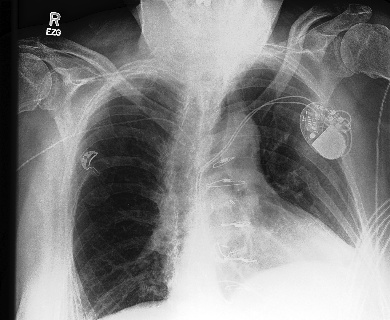

In [3]:
texts = [
    'lungs remain severely hyperinflated with upper lobe emphysema',
    'opacity left costophrenic angle is new since prior exam ___ represent some loculated fluid cavitation unlikely',
]
task_image = Image.open(INPUT_PATH).convert('RGB')
task_inputs = processor(text=texts, images=task_image, return_tensors='pt', padding=True)
with torch.inference_mode():
    outputs = model(**task_inputs)
logits = outputs['logits'].float().cpu()
payload = {
    'task': 'image_text_encoding_similarity',
    'model': 'MedCLIP-ViT',
    'input': str(INPUT_PATH),
    'input_sha256': sha256(INPUT_PATH),
    'texts': texts,
    'logits': logits.tolist(),
    'image_embedding_shape': list(outputs['img_embeds'].shape),
    'text_embedding_shape': list(outputs['text_embeds'].shape),
    'device': torch.cuda.get_device_name(DEVICE),
}
result_path = OUTPUT_DIR / 'medclip_encode.json'
result_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
print('image:', INPUT_PATH.name, 'size:', task_image.size)
display(task_image)
for text, score in zip(texts, logits[0].tolist()):
    print(f'{score:.6f}  {text}')
print('image_embedding_shape:', payload['image_embedding_shape'])
print('text_embedding_shape:', payload['text_embedding_shape'])
print('saved:', result_path)


### 2.3 任务二：CheXpert 提示分类

`generate_chexpert_class_prompts(n=10)` 为每个类别生成十条候选描述，`PromptClassifier(ensemble=True)` 对每类提示的 logits 求平均。这里固定随机种子以便同一组资产重复运行，并将每个类别的分数和排序写入单独结果文件。


In [4]:
import random

from medclip.prompts import generate_chexpert_class_prompts, process_class_prompts

random.seed(0)
classifier = PromptClassifier(model, ensemble=True).to(DEVICE)
classifier.eval()
classification_inputs = processor(images=image, return_tensors='pt')
classification_inputs['prompt_inputs'] = process_class_prompts(generate_chexpert_class_prompts(n=10))
with torch.inference_mode():
    classification = classifier(**classification_inputs)
class_logits = classification['logits'].float().cpu()[0]
class_names = list(classification['class_names'])
ranking = sorted(
    [{'class_name': name, 'logit': float(score)} for name, score in zip(class_names, class_logits.tolist())],
    key=lambda item: item['logit'],
    reverse=True,
)
payload = {
    'task': 'chexpert_prompt_classification',
    'model': 'MedCLIP-ViT',
    'input': str(INPUT_PATH),
    'input_sha256': sha256(INPUT_PATH),
    'prompt_count_per_class': 10,
    'ranking': ranking,
    'device': torch.cuda.get_device_name(DEVICE),
}
result_path = OUTPUT_DIR / 'medclip_prompt_classification.json'
result_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
for item in ranking:
    print(f"{item['logit']:.6f}  {item['class_name']}")
print('saved:', result_path)


sample 10 num of prompts for Atelectasis from total 210
sample 10 num of prompts for Cardiomegaly from total 15
sample 10 num of prompts for Consolidation from total 192
sample 10 num of prompts for Edema from total 18
sample 10 num of prompts for Pleural Effusion from total 54
0.452003  Cardiomegaly
0.433376  Consolidation
0.399099  Atelectasis
0.372964  Edema
0.358434  Pleural Effusion
saved: /tmp/medclip-run/outputs/medclip_prompt_classification.json


---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以上游官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.
